In [27]:
import pandas as pd
import spacy
nlp = spacy.load('en_core_web_sm')

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [29]:
def lower_replace(series):
    output = series.str.lower()
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'[^\w\s]', '', regex=True)
    return output

def token_lemma_nonstop(text):
    doc = nlp(text)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = ' '.join(output)
    return output 

def filter_pos(text, pos_list=['NOUN', 'PROPN']):
    doc = nlp(text)
    output = [(token.text) for token in doc if token.pos_ in pos_list]
    output = ' '.join(output)
    return output

In [30]:
def nlp_pipeline(series):
    output = lower_replace(series)
    output = output.apply(token_lemma_nonstop)
    return output

In [31]:
def payment_context(row):
    org = str(row.get("Organization Name", "")).strip()
    typ = str(row.get("Type", "")).strip()
    ben = str(row.get("Beneficiary Name", "")).strip()
    desc = str(row.get("Description", "")).strip()

    if org == "OFFICE OF THE SPECIAL ADVISER TO THE PRESIDENT ON NIGER DELTA":
        return "PRESIDENTIAL AMNESTY PROGRAMME"
    elif ben == "FEDERAL INLAND REVENUE SERVICES":
        return ben
         return f"to {ben} for {desc}"
    else:
        return f"{desc}"

In [32]:
df = pd.read_excel("Sample Data.xlsx")
pd.set_option('display.max_colwidth', None)


In [33]:
df["Context"] = df.apply(payment_context, axis=1)

In [34]:
df['Context'] = df['Context'].fillna("")
df.isna().sum()

Payment No                 0
Payer Code                 0
Organization Name          0
Beneficiary Name           0
Amount                     0
Description               23
Date                       0
Month                      0
Type                     155
Year                     155
COFOG                    155
Ministry                 155
Organization_Cleaned     167
Economic Code              0
NCoA Description           0
Linkage Flag            8530
COVID-19 Flag           8717
Context                    0
dtype: int64

In [35]:
df = df.astype(str)

In [36]:
abbrev_map = {
    'pymnt': 'payment',
    'iro': 'in respect of',
    'qty': 'quantity',
    'no': 'number',
    'const': 'construction',
    'rehab': 'rehabilitation',
    'renov': 'renovation',
    'veh': 'vehicle',
    'maint': 'maintenance',
    'rep': 'repair',
    'suppl': 'supply',
    'matls': 'materials',
    'ago': 'diesel fuel',
    'ict': 'information technology',
    'nhis': 'national health insurance scheme',
    'pencom': 'national pension commission',
    'nhf': 'national housing fund',
    'pms': 'petrol',
}
for k, v in abbrev_map.items():
    df['Context'] = df['Context'].replace(k, v)

In [54]:
vocab_size = len(vectorizer.vocabulary_)
print("Vocabulary size:", vocab_size)

Vocabulary size: 21622


In [55]:
import numpy as np
feature_names = vectorizer.get_feature_names_out()
importance = np.abs(coefficients).mean(axis=0)

top_terms = pd.Series(importance, index=feature_names)

print(top_terms.sort_values(ascending=False).reset_index().head(20))

             index         0
0              nhf  0.202090
1             nhis  0.194654
2     construction  0.189545
3             ctss  0.183312
4   rehabilitation  0.170110
5          subsidy  0.160328
6           supply  0.150126
7              tax  0.128693
8      empowerment  0.127271
9           repair  0.127094
10            meal  0.121554
11        zedvance  0.120413
12         pension  0.115311
13         payment  0.113243
14            2020  0.113160
15     electricity  0.110918
16    meal subsidy  0.110454
17       equipment  0.109371
18       provision  0.105058
19           state  0.101325


<Axes: >

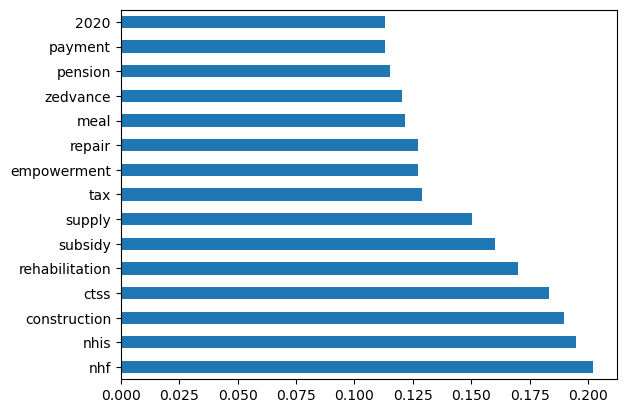

In [56]:
top_terms.sort_values(ascending=False).head(15).plot.barh()

In [47]:
classes = model.classes_
top_keywords = {}

for i, code in enumerate(classes):

    coef = coefficients[i]

    top_indices = np.argsort(coef)[-10:]  # top 10 words

    keywords = [feature_names[j] for j in top_indices]

    top_keywords[code] = keywords

keywords_df = pd.DataFrame.from_dict(
    top_keywords,
    orient="index"
)

keywords_df.columns = [f"Keyword_{i+1}" for i in range(10)]

keywords_df.to_excel("top_keywords_by_economic_code.xlsx")

In [57]:
df["Economic Code"].unique().size

85

# Logistic Regression

In [37]:
df["Description_Cleaned"] = nlp_pipeline(df["Context"])

X_train, X_test, y_train, y_test = train_test_split(df['Description_Cleaned'], df['Economic Code'], test_size=0.2, random_state=992)

vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [58]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      210101       0.89      0.82      0.85        38
      210201       1.00      0.94      0.97        34
    21030103       0.00      0.00      0.00         3
        2202       1.00      0.89      0.94        19
      220201       1.00      0.73      0.84        37
    22020201       1.00      0.96      0.98        24
    22020203       1.00      0.33      0.50         3
      220203       1.00      0.57      0.73        14
    22020301       0.00      0.00      0.00         3
    22020305       0.50      0.50      0.50         2
    22020306       0.00      0.00      0.00         1
    22020307       1.00      0.71      0.83         7
    22020309       1.00      0.17      0.29         6
    22020310       1.00      0.40      0.57         5
    22020311       1.00      0.92      0.96        53
      220204       0.00      0.00      0.00         4
    22020404       0.00      0.00      0.00         5
      220205       0.67    

C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

### Cross-validation

In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    vectorizer.fit_transform(df["Description_Cleaned"]),
    df["Economic Code"],
    cv=5,
    scoring="f1_weighted"
)

print("Cross-validation F1 scores:", scores)
print("Average F1 score:", scores.mean())

C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross-validation F1 scores: [0.70716813 0.80050575 0.8663014  0.87917197 0.80976977]
Average F1 score: 0.8125834053969264


### Hyperparameter tuning

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(df["Description_Cleaned"], df["Economic Code"])

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'clf__C': 10, 'tfidf__ngram_range': (1, 1)}
Best Score: 0.8859441634336133


### Confusion Matrix

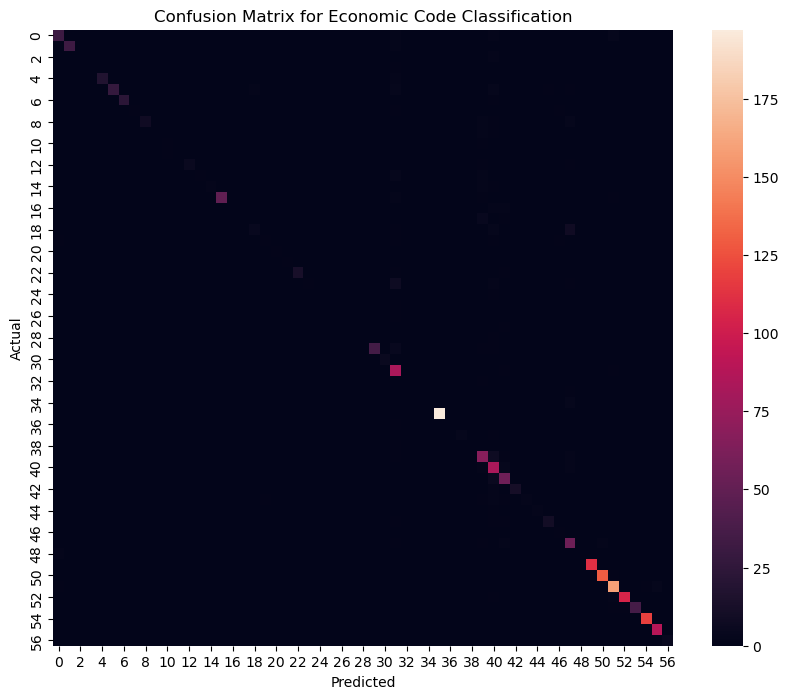

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Economic Code Classification")
plt.show()

# Support Vector Machine 

In [37]:
df["Description_Cleaned"] = nlp_pipeline(df["Context"])

X_train, X_test, y_train, y_test = train_test_split(df['Description_Cleaned'], df['Economic Code'], test_size=0.2, random_state=992)

vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [24]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
      210101       0.92      0.87      0.89        38
      210201       0.97      0.94      0.96        34
    21030103       1.00      1.00      1.00         3
        2202       1.00      0.89      0.94        19
      220201       1.00      0.84      0.91        37
    22020201       0.92      1.00      0.96        24
    22020203       1.00      0.67      0.80         3
      220203       1.00      0.64      0.78        14
    22020301       1.00      0.67      0.80         3
    22020305       0.67      1.00      0.80         2
    22020306       1.00      1.00      1.00         1
    22020307       0.86      0.86      0.86         7
    22020309       0.75      1.00      0.86         6
    22020310       0.80      0.80      0.80         5
    22020311       1.00      0.94      0.97        53
      220204       0.00      0.00      0.00         4
    22020404       1.00    

C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0

### Cross-validation

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    vectorizer.fit_transform(df["Description_Cleaned"]),
    df["Economic Code"],
    cv=5,
    scoring="f1_weighted"
)

print("Cross-validation F1 scores:", scores)
print("Average F1 score:", scores.mean())

C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross-validation F1 scores: [0.77597351 0.86664248 0.94091572 0.93950459 0.92841331]
Average F1 score: 0.8902899232619313


### Hyperparameter tuning

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(df["Description_Cleaned"], df["Economic Code"])

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

C:\Users\HP\anaconda3\envs\nlp_basics\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'clf__C': 10, 'tfidf__ngram_range': (1, 1)}
Best Score: 0.8859441634336133


### Confusion Matrix

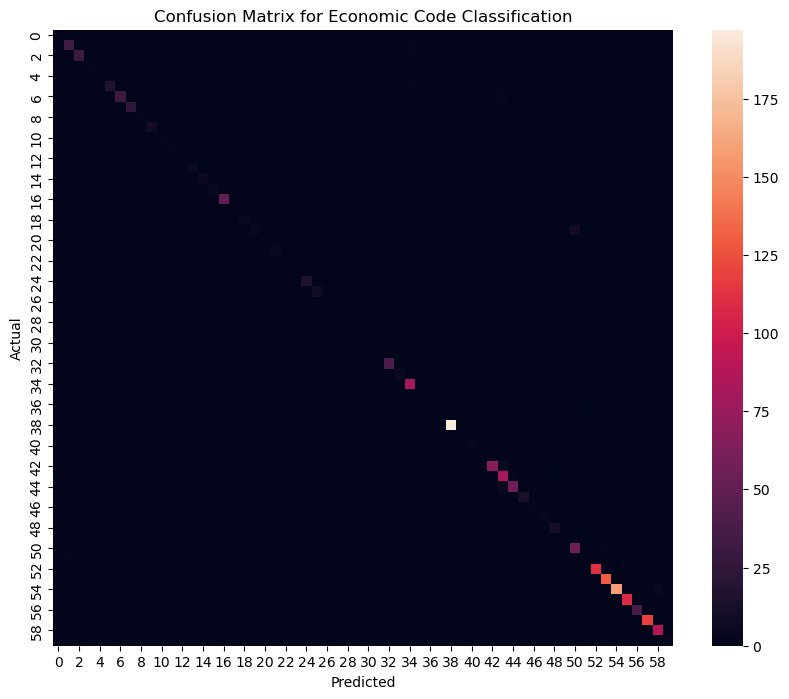

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Economic Code Classification")
plt.show()

In [41]:
unlabelled = pd.read_excel('total_payments.xlsx')

unlabelled["Context"] = unlabelled.apply(payment_context, axis=1)
unlabelled["Context"] = unlabelled["Context"].fillna("")
unlabelled["Context"] = unlabelled["Context"].astype(str)
unlabelled["Description_Cleaned"] = nlp_pipeline(unlabelled["Context"])
unlabelled['Description_Cleaned'] = unlabelled['Description_Cleaned'].fillna("")


print(unlabelled_vec.shape)
print(model.n_features_in_)

unlabelled_vec = vectorizer.transform(unlabelled['Description_Cleaned'])
unlabelled['ECONOMIC CODE'] = model.predict(unlabelled_vec)

(398948, 21622)
21622


In [42]:
unlabelled["ECONOMIC CODE"] = unlabelled["ECONOMIC CODE"].astype('int64')

In [43]:
ncoa = pd.read_excel("./references/NCOA.xlsx", sheet_name="Expenditure")
ncoa_clean = (
ncoa[
["ECONOMIC CODE", "FEDERAL GOVERNMENT (A)"]
]
)

In [44]:
unlabelled = unlabelled.merge(ncoa_clean, how="left", on=["ECONOMIC CODE"])

In [45]:
unlabelled.rename(columns={'FEDERAL GOVERNMENT (A)': 'Category'}, inplace=True)


In [46]:
unlabelled.to_excel('total_payments.xlsx', index=False)

In [64]:
ncoa = pd.read_excel("./references/NCOA Truncated.xlsx", sheet_name="Expenditure")

In [65]:
ncoa.columns

Index(['ECONOMIC CODE', 'FEDERAL GOVERNMENT (A)'], dtype='object')

In [50]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

In [66]:
model = SentenceTransformer('all-MiniLM-L6-v2')
df = pd.read_excel("Sample Data.xlsx")
sample = df["Description"]
sample = (
    df["Description"]
      .fillna("")              
      .astype(str)             
      .str.strip()            
)

payment_embeds = model.encode(sample.tolist(), convert_to_tensor=True)
ncoa_embeds = model.encode(ncoa['FEDERAL GOVERNMENT (A)'].tolist(), convert_to_tensor=True)

# Match each payment to closest NCOA description
results = []
descriptions = []
for i, p_emb in enumerate(payment_embeds):
    sims = util.cos_sim(p_emb, ncoa_embeds)[0]
    best_idx = sims.argmax().item()
    results.append(ncoa.iloc[best_idx]['ECONOMIC CODE'])
    descriptions.append(ncoa.iloc[best_idx]['FEDERAL GOVERNMENT (A)'])

df['Predicted_Code'] = results
df['Predicted_Description'] = descriptions
df.to_csv('classified_payments.csv', index=False)